# 1. DATAPROCESSING (LOWERCASE, TOKENIZATION, STOPWORDS)

In [2]:
input = "Brack Obama is a prime minister of USA in the year of 2015. NARENDRA MODI is the prime minister of INDIA"
print(input)

Brack Obama is a prime minister of USA in the year of 2015. NARENDRA MODI is the prime minister of INDIA


In [3]:
#(1)lowercase
lowercase = input.lower()
print("LOWERCSE = ", lowercase)

#re
#pip install re
import re
lowercase_re = re.sub('2015', '2025', lowercase)
print("REGULAR EXP1 = ", lowercase_re)
lowercase_re = re.sub('[a-m]', '*', lowercase)
print("REGULAR EXP2 = ", lowercase_re)
lowercase_re = re.sub('/d', '-', lowercase)
print("REGULAR EXP3 = ", lowercase_re)

LOWERCSE =  brack obama is a prime minister of usa in the year of 2015. narendra modi is the prime minister of india
REGULAR EXP1 =  brack obama is a prime minister of usa in the year of 2025. narendra modi is the prime minister of india
REGULAR EXP2 =  *r*** o**** *s * pr*** **n*st*r o* us* *n t** y**r o* 2015. n*r*n*r* *o** *s t** pr*** **n*st*r o* *n***
REGULAR EXP3 =  brack obama is a prime minister of usa in the year of 2015. narendra modi is the prime minister of india


In [4]:
#(2)Tokenization
import nltk
from nltk import word_tokenize, sent_tokenize

word_tokens = word_tokenize(input)
print("WORD TOKENS = ", word_tokens)
print(len(word_tokens))
sent_tokens = sent_tokenize(input)
print("SENT TOKENS = ", sent_tokens)
print(len(sent_tokens))

WORD TOKENS =  ['Brack', 'Obama', 'is', 'a', 'prime', 'minister', 'of', 'USA', 'in', 'the', 'year', 'of', '2015', '.', 'NARENDRA', 'MODI', 'is', 'the', 'prime', 'minister', 'of', 'INDIA']
22
SENT TOKENS =  ['Brack Obama is a prime minister of USA in the year of 2015.', 'NARENDRA MODI is the prime minister of INDIA']
2


In [5]:
#(3)stopwords Removal
from nltk.corpus import stopwords
#print(stopwords.fileids())
stopwords = set(stopwords.words('english'))
#print("\n", stopwords)

tokens_stopwords = []
for token in word_tokens:
    if token not in stopwords:
        tokens_stopwords.append(token)
print(' '.join(tokens_stopwords))

Brack Obama prime minister USA year 2015 . NARENDRA MODI prime minister INDIA


# 2. DATA PREPROCESSING (STEMMER, LEMMATIZER, POS TAGS)

In [6]:
#Stemmer
stemming = []
from nltk import PorterStemmer
for word in tokens_stopwords:
    stemming.append(PorterStemmer().stem(word))
print(stemming)

['brack', 'obama', 'prime', 'minist', 'usa', 'year', '2015', '.', 'narendra', 'modi', 'prime', 'minist', 'india']


In [7]:
#Lemmatizer
from nltk import WordNetLemmatizer
lma = []
for word in tokens_stopwords:
    lma.append(WordNetLemmatizer().lemmatize(word))
print(lma)

['Brack', 'Obama', 'prime', 'minister', 'USA', 'year', '2015', '.', 'NARENDRA', 'MODI', 'prime', 'minister', 'INDIA']


In [8]:
#POS Tags
from nltk import pos_tag
print(pos_tag(word_tokens))

[('Brack', 'NNP'), ('Obama', 'NNP'), ('is', 'VBZ'), ('a', 'DT'), ('prime', 'JJ'), ('minister', 'NN'), ('of', 'IN'), ('USA', 'NNP'), ('in', 'IN'), ('the', 'DT'), ('year', 'NN'), ('of', 'IN'), ('2015', 'CD'), ('.', '.'), ('NARENDRA', 'NNP'), ('MODI', 'NNP'), ('is', 'VBZ'), ('the', 'DT'), ('prime', 'JJ'), ('minister', 'NN'), ('of', 'IN'), ('INDIA', 'NNP')]


# 3. NER

In [9]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk

input = "Brack Obama is a prime minister of USA in the year of 2015. NARENDRA MODI is the prime minister of INDIA"
ner = ne_chunk(pos_tag(word_tokenize(input)))
#print(ner)
from nltk.tree import Tree
named_entity = []
for subtree in ner:
    if isinstance(subtree, Tree):
        entity = "".join([token for token, pos in subtree.leaves()])
        named_entity.append(entity)
        print(named_entity)

['Brack']
['Brack', 'Obama']
['Brack', 'Obama', 'USA']
['Brack', 'Obama', 'USA', 'NARENDRA']
['Brack', 'Obama', 'USA', 'NARENDRA', 'INDIA']


In [10]:
#NER using spacy
import spacy
nlp = spacy.load("en_core_web_sm")
text = "Barack Obama went as a prime minister of USA in the year of 2015.PM MODI is the prime minister of INDIA."
doc = nlp(text)
named_entity = []
for ent in doc.ents:
    named_entity.append(ent.text)
    print(named_entity)

['Barack Obama']
['Barack Obama', 'USA']
['Barack Obama', 'USA', 'the year']
['Barack Obama', 'USA', 'the year', '2015.PM MODI']
['Barack Obama', 'USA', 'the year', '2015.PM MODI', 'INDIA']


# 4. PREDICTIVE ANALYSIS

In [11]:
# TF-IDF
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
# pip install scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

stopwords = set(stopwords.words('english'))
ps = PorterStemmer()
vector = TfidfVectorizer()

documents= [ "apple boy cat", "apple cat dog", "dog egg fan" ]

preprocessed = []
for doc in documents:
    tokenization = word_tokenize(doc)
    stop = [ps.stem(word) for word in tokenization if word not in stopwords]
    preprocessed.append(" ".join(stop))
print(preprocessed)
word_score = vector.fit_transform(preprocessed)
print(word_score)

['appl boy cat', 'appl cat dog', 'dog egg fan']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (3, 6)>
  Coords	Values
  (0, 0)	0.5178561161676974
  (0, 1)	0.680918560398684
  (0, 2)	0.5178561161676974
  (1, 0)	0.5773502691896257
  (1, 2)	0.5773502691896257
  (1, 3)	0.5773502691896257
  (2, 3)	0.4736296010332684
  (2, 4)	0.6227660078332259
  (2, 5)	0.6227660078332259


# 5. SIMPLE LINEAR REGRESSION

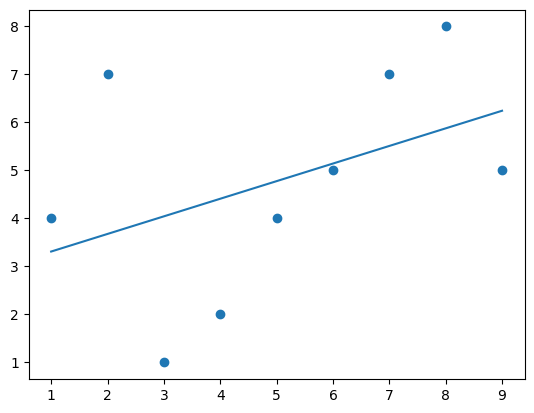

In [12]:
import matplotlib.pyplot as plt

x = [1,2,3,4,5,6,7,8,9]
y = [4,7,1,2,4,5,7,8,5]

def slr(x):
    return slope * x + intercept

from scipy import stats
slope, intercept, r, p, std_err = stats.linregress(x,y)

model = list(map(slr, x))
plt.plot(x, model)

plt.scatter(x,y)
plt.show()

# 6. MLR

In [13]:
import pandas as pd
iris = pd.read_csv("IRIS.csv")
print(iris)
import numpy as np

x = iris[['SepalLengthCm', 'SepalWidthCm']]
y = iris.PetalLengthCm

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

from sklearn.linear_model import LinearRegression
LR = LinearRegression()
training = LR.fit(x_train, y_train)
y_pred = LR.predict(x_test)
print(y_pred)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

# 7. SLR & MLR with Performance Metrics:

In [14]:
import pandas as pd
iris = pd.read_csv("IRIS.csv")
print(iris)

import numpy as np

x = iris[['SepalLengthCm', 'SepalWidthCm']]
y = iris.PetalLengthCm

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

from sklearn.linear_model import LinearRegression
LR = LinearRegression()

training = LR.fit(x_train, y_train)
y_pred = LR.predict(x_test)
print(y_pred, "\n")

#pip install numpy
import numpy as np
from sklearn import metrics

MAE = metrics.mean_absolute_error(y_test, y_pred)
print("Mean Absoute Error: ", MAE)
MSE = metrics.mean_squared_error(y_test, y_pred)
print("Mean Squeared Error: ", MSE)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
print("RMSE: ", RMSE)


import numpy as np

x = iris[['SepalLengthCm']]
y = iris.PetalLengthCm

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

from sklearn.linear_model import LinearRegression
LR = LinearRegression()

training = LR.fit(x_train, y_train)
y_pred = LR.predict(x_test)
print(y_pred, "\n")

#pip install numpy
import numpy as np
from sklearn import metrics

MAE = metrics.mean_absolute_error(y_test, y_pred)
print("Mean Absoute Error: ", MAE)
MSE = metrics.mean_squared_error(y_test, y_pred)
print("Mean Squeared Error: ", MSE)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
print("RMSE: ", RMSE)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

# 8. KNN

In [15]:
from sklearn import datasets
iris = datasets.load_iris()

x = iris.data
y = iris.target

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

train = knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(y_pred)
y_auc = knn.predict_proba(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
Accuracy = accuracy_score(y_test, y_pred)
Precision = precision_score(y_test, y_pred, average='macro')
Recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_auc, multi_class='ovr')

print("\nAccuracy : ", Accuracy)
print("Precision : ", Precision)
print("Recall : ", Recall)
print("F1-SCORE : ", f1)
print("AUC : ", auc)

[1 0 2 0 0 2 2 1 2 0 2 2 0 0 2 1 2 1 0 1 2 1 1 1 1 2 0 0 0 0]

Accuracy :  0.9666666666666667
Precision :  0.9666666666666667
Recall :  0.9666666666666667
F1-SCORE :  0.9649122807017543
AUC :  0.9965696649029981


# 9. DECISION TREE

In [16]:
from sklearn import datasets
iris = datasets.load_iris()

x = iris.data
y = iris.target

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8)

from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()

train = DT.fit(x_train, y_train)
y_pred = DT.predict(x_test)
print(y_pred)
y_auc = DT.predict_proba(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
Accuracy = accuracy_score(y_test, y_pred)
Precision = precision_score(y_test, y_pred, average='macro')
Recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_auc, multi_class='ovr')

print("\nAccuracy : ", Accuracy)
print("Precision : ", Precision)
print("Recall : ", Recall)
print("F1-SCORE : ", f1)
print("AUC : ", auc)

[1 1 1 2 0 1 2 1 0 0 2 0 0 0 2 0 1 2 0 0 0 2 1 0 0 1 1 2 1 0]

Accuracy :  0.9666666666666667
Precision :  0.9666666666666667
Recall :  0.9583333333333334
F1-SCORE :  0.9602339181286549
AUC :  0.9712301587301587


# 10. RANDOM FOREST

In [17]:
from sklearn import datasets
iris = datasets.load_iris()

x = iris.data
y = iris.target

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8)

from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()

train = RF.fit(x_train, y_train)
y_pred = RF.predict(x_test)
print(y_pred)
y_auc = RF.predict_proba(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
Accuracy = accuracy_score(y_test, y_pred)
Precision = precision_score(y_test, y_pred, average='macro')
Recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_auc, multi_class='ovr')

print("\nAccuracy : ", Accuracy)
print("Precision : ", Precision)
print("Recall : ", Recall)
print("F1-SCORE : ", f1)
print("AUC : ", auc)

[1 0 2 0 2 0 2 1 0 0 2 0 1 1 1 0 0 1 2 2 0 0 2 0 0 1 2 1 1 1]

Accuracy :  0.9333333333333333
Precision :  0.9249999999999999
Recall :  0.9249999999999999
F1-SCORE :  0.9249999999999999
AUC :  0.992878787878788


# 11. SVM

In [18]:
from sklearn import datasets
iris = datasets.load_iris()

x = iris.data
y = iris.target

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8)

from sklearn import svm
svc_cl = svm.SVC(probability=True)

train = svc_cl.fit(x_train, y_train)
y_pred = svc_cl.predict(x_test)
print(y_pred)
y_auc = svc_cl.predict_proba(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
Accuracy = accuracy_score(y_test, y_pred)
Precision = precision_score(y_test, y_pred, average='macro')
Recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_auc, multi_class='ovr')

print("\nAccuracy : ", Accuracy)
print("Precision : ", Precision)
print("Recall : ", Recall)
print("F1-SCORE : ", f1)
print("AUC : ", auc)

[0 0 0 0 1 1 2 1 0 2 1 1 0 0 0 2 2 2 1 0 0 1 1 1 2 1 1 2 0 2]

Accuracy :  0.9666666666666667
Precision :  0.9696969696969697
Recall :  0.9629629629629629
F1-SCORE :  0.9645191409897292
AUC :  1.0


# 12. Implementation of EDA with Automated Profiling on IRIS Dataset

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\kumar\postagging\IRIS.csv")
df.head(10)
df.info()

from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='EDA.html')

from IPython.core.display import display, HTML
display(HTML(prof.to_html()))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


ImportError: Numba needs NumPy 2.1 or less. Got NumPy 2.3.

# 13. Implementation of Data Cleaning on IRIS Dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\kumar\postagging\IRIS.csv")
df.head(10)
df.info()

# Missing values Handling
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)
print("Missing values after filling:\n", df.isnull().sum())

# Handling Duplicate Values
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
df.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {df.shape}")

# Handling Null Values
print("Null values before dropping:\n", df.isnull().sum())
df.dropna(inplace=True)
print(f"Shape after dropping nulls: {df.shape}")
print("Null values after dropping:\n", df.isnull().sum())

# Handling Outliers
Q1 = df['SepalLengthCm'].quantile(0.25)
Q3 = df['SepalLengthCm'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['SepalLengthCm'] >= lower_bound) & (df['SepalLengthCm'] <= upper_bound)]
print(f"Data shape after removing outliers: {df.shape}")

# Final cleaned data
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
Missing values after filling:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Number of duplicate rows: 0
Data shape after removing duplicates: (150, 6)
Null values before dropping:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Shape after dropping nulls: (150, 6)
Null values after dropping:
 Id               0
SepalLe

C:\Users\kumar\AppData\Local\Temp\ipykernel_26232\770745455.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\kumar\AppData\Local\Temp\ipykernel_26232\770745455.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

# 14. Implementation of Data Transformation Techniques on IRIS Dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\kumar\postagging\IRIS.csv")
df.head(10)
df.info()

# Normalization Technique
from sklearn.preprocessing import MinMaxScaler
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\n--- Normalized Data (First 5 rows) ---")
print(df_normalized[numeric_cols].head())

# Scaling Technique
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\n--- Scaled Data (First 5 rows) ---")
print(df_scaled[numeric_cols].head())

# Standardization Technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\n--- Standardized Data (First 5 rows) ---")
print(df_standardized[numeric_cols].head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

--- Normalized Data (First 5 rows) ---
         Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0  0.000000       0.222222      0.625000       0.067797      0.041667
1  0.006711       0.166667      0.416667       0.067797      0.041667
2  0.013423       0.111111      0.500000       0.050847      0.041667
3  0.020134       0.083333      0.458333       0.084746      0.041667
4  0.026846       0.194444      0.666667       0.067797      0.041667

--- Scaled Data (Firs

# KMEANS CLUSTERING

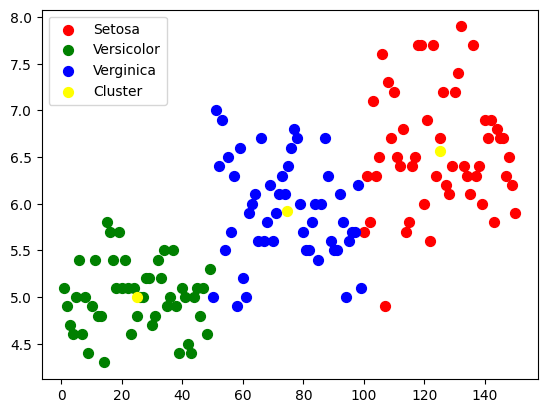

In [27]:
import pandas as pd
iris = pd.read_csv("IRIS.csv")

x = iris.iloc[:,:-1].values
y = iris.iloc[:, -1].values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3)
y_pred = kmeans.fit_predict(x)
#print(kmeans.cluster_centers_)

import matplotlib.pyplot as plt
plt.scatter(x[y_pred == 0,0], x[y_pred == 0,1], s=50, c='red', label='Setosa')
plt.scatter(x[y_pred == 1,0], x[y_pred == 1,1], s=50, c='green', label='Versicolor')
plt.scatter(x[y_pred == 2,0], x[y_pred == 2,1], s=50, c='blue', label='Verginica')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=50, c='yellow', label='Cluster')

plt.legend()
plt.show()

# 15. KMEANS Clustering in 3D

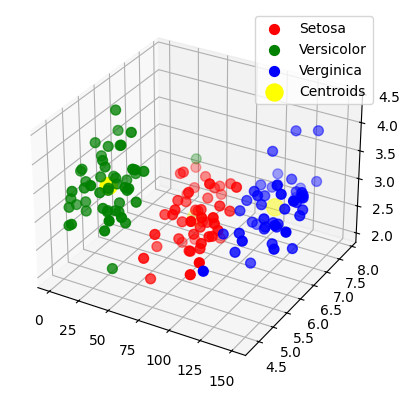

In [ ]:
import pandas as pd
iris = pd.read_csv("IRIS.csv")

x = iris.iloc[:,:-1].values
y = iris.iloc[:, -1].values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3)
y_pred = kmeans.fit_predict(x)
# print(kmeans.cluster_centers_)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x[y_pred == 0,0], x[y_pred == 0,1], x[y_pred == 0,2], s=50, c='red', label='Setosa')
ax.scatter(x[y_pred == 1,0], x[y_pred == 1,1], x[y_pred == 1,2], s=50, c='green', label='Versicolor')
ax.scatter(x[y_pred == 2,0], x[y_pred == 2,1], x[y_pred == 2,2], s=50, c='blue', label='Verginica')
ax.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], kmeans.cluster_centers_[:,2], s=150, c='yellow', label='Centroids')

plt.legend()
plt.show()

# 16. Hierarchical Clustering

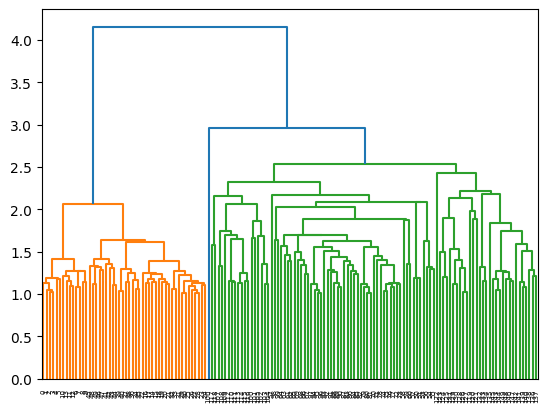

In [ ]:
import pandas as pd
iris = pd.read_csv("IRIS.csv")

x = iris.iloc[:,:-1].values
y = iris.iloc[:, -1].values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 3)
y_pred = hc.fit_predict(x)
#print(kmeans.cluster_centers_)

import matplotlib.pyplot as plt
plt.scatter(x[kmeans == 0,0], x[kmeans == 0,1], s=50, c='red', label='Setosa')
plt.scatter(x[kmeans == 1,0], x[kmeans == 1,1], s=50, c='green', label='Versicolor')
plt.scatter(x[kmeans == 2,0], x[kmeans == 2,1], s=50, c='blue', label='Verginica')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=150, c='yellow', label='Centroids')

from scipy.cluster.hierarchy import dendrogram, linkage
dendrogram(linkage(x))
plt.show()

# 17. Conversion of Binary Image to RGB Image

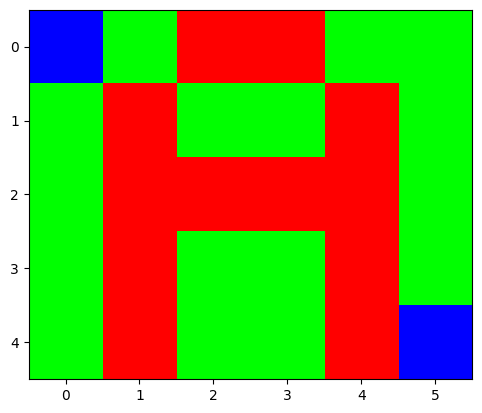

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = [0,0,1,1,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0]
B = [0,1,1,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0]

def bin_to_rgb(array, shape):
    rgb_array = np.zeros((shape[0], shape[1], 3))
    for i in range(shape[0]):
        for j in range(shape[1]):
            if array[i*shape[1]+j] == 1:
                rgb_array[i,j] = [1,0,0]
            else:
                rgb_array[i,j] = [0,1,0]
    return rgb_array 

rgb_A = bin_to_rgb(A, (5,6))
rgb_A[0,0] = [0,0,1]
rgb_A[4,5] = [0,0,1]
plt.imshow(rgb_A)
plt.show()

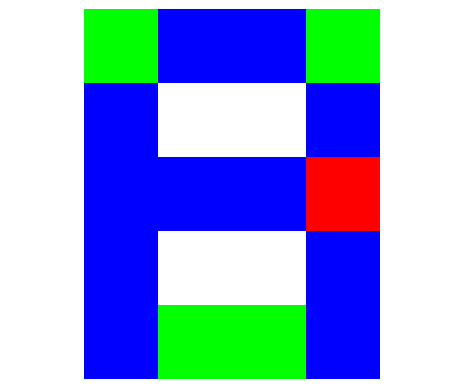

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = [0,0,1,1,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0]
B = [0,1,1,1,1,0,0,1,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,1,1,1,1,0]

def overlap_images(A, B, shape):
    rgb_array = np.zeros((shape[0], shape[1], 3))
    for i in range(shape[0]):
        for j in range(shape[1]):
            idx = i*shape[1] + j
            if A[idx] == 1 and B[idx] == 1:
                rgb_array[i,j] = [0,0,1]  # Blue (overlap)
            elif A[idx] == 1:
                rgb_array[i,j] = [1,0,0]  # Red
            elif B[idx] == 1:
                rgb_array[i,j] = [0,1,0]  # Green
            else:
                rgb_array[i,j] = [1,1,1]  # White background
    return rgb_array

rgb_AB = overlap_images(A, B, (5,6))
plt.imshow(rgb_AB)
plt.axis("off")
plt.show()


# 18. DIMENSIONALTY REDUCTION TECHNIQUE

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

doc = [
    "CUTM is located in Paralakhemundi",
    "Paralakhemundi is located in Odisha",
    "Odisha is a state"    
]

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(doc)
words = tfidf.get_feature_names_out()
print(words)
print("Original shape = ", X.shape, "\n")
print(X)

#eigen val, vec, cov, mean
X_centered = X - X.mean(axis=0)
print(X_centered, "\n")
cov = np.cov(X_centered, rowvar=False)
print(cov, "\n")

eig_vals, eig_vecs = np.linalg.eigh(cov)
idx  = eig_vals.argsort()[::-1]
eig_vecs = eig_vecs[:, idx[:2]]

X_pca = np.dot(X_centered, eig_vecs)
print("Reduced shape = ", X_pca.shape)
print(X_pca)

['cutm' 'in' 'is' 'located' 'odisha' 'paralakhemundi' 'state']
Original shape =  (3, 7) 

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (3, 7)>
  Coords	Values
  (0, 0)	0.5694308628404254
  (0, 2)	0.33631504064053513
  (0, 3)	0.43306684852870914
  (0, 1)	0.43306684852870914
  (0, 5)	0.43306684852870914
  (1, 2)	0.3619650009883935
  (1, 3)	0.46609584262774545
  (1, 1)	0.46609584262774545
  (1, 5)	0.46609584262774545
  (1, 4)	0.46609584262774545
  (2, 2)	0.4254405389711991
  (2, 4)	0.5478321549274363
  (2, 6)	0.7203334490549893
[[ 0.37962058  0.13334595 -0.03825849  0.13334595 -0.337976    0.13334595
  -0.24011115]
 [-0.18981029  0.16637495 -0.01260853  0.16637495  0.12811984  0.16637495
  -0.24011115]
 [-0.18981029 -0.2997209   0.05086701 -0.2997209   0.20985616 -0.2997209
   0.4802223 ]] 

[[ 0.10808384  0.03796565 -0.01089278  0.03796565 -0.09622698  0.03796565
  -0.06836335]
 [ 0.03796565  0.06764719 -0.01122263  0.06764719 -0.04332504  0.